# EDA 


<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\peljo\AppData\Local\Temp\ipykernel_30240\3132240113.py:2: SyntaxWarning: invalid escape sequence '\p'
  police_press_df = pd.read_csv("Datasets\police_press_releases.csv")
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\peljo\AppData\Local\Temp\ipykernel_30240\667783131.py:2: SyntaxWarning: invalid escape sequence '\p'
  output_file_path_one = 'Datasets\police_press_releases_cleaned.csv'
<>:2: SyntaxWarning: invalid escape sequence '\l'
C:\Users\peljo\AppData\Local\Temp\ipykernel_30240\4037244084.py:2: SyntaxWarning: invalid escape sequence '\l'
  local_news_df = pd.read_csv("Datasets\local_news_articles.csv")
<>:2: SyntaxWarning: invalid escape sequence '\l'
C:\Users\peljo\AppData\Local\Temp\ipykernel_30240\880791641.py:2: SyntaxWarning: invalid escape sequence '\l'
  output_file_path_two = 'Datasets\local_news_articles_cleaned.csv'
<>:9: SyntaxWarning: invalid escape sequence '\F'
C:\Users\peljo\AppData\Local\Temp\

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           111 non-null    object
 1   date_published  111 non-null    object
 2   date_modified   111 non-null    object
 3   content         111 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB


                                               title date_published  \
0  Collision between a car and a motorbike in Żur...     2025-10-09   
1                    Car-motorcycle traffic accident     2025-06-20   
2              Car-motorcycle collision in Ħal Qormi     2025-05-12   
3     Collision between motorcycle and car in Għaxaq     2025-07-30   
4                           Car-motorcycle collision     2025-04-07   

  date_modified                                            content  
0    2025-10-09  Today, at around 0930hrs, the Police were info...  
1    2025-06-20  Yesterda

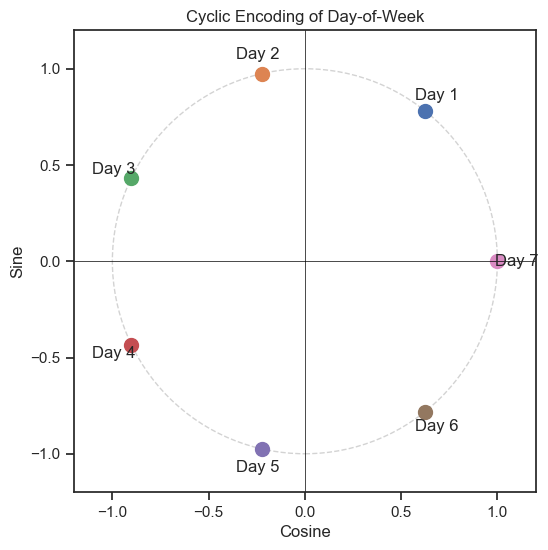

In [69]:
%run "1_data_preperation.ipynb"

In [70]:
#Import all the libraries

import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.feature_extraction.text import TfidfVectorizer #Vecctorizing Text
from scipy.stats import spearmanr


In [71]:
#Import the Finalised dataset from step 1
df = pd.read_csv("Datasets/Finalized_Dataset_Unstardadized.csv", sep=",", header=0)
print(df.head(5)) # Display the head

                                             content  temperature_2m_mean  \
0  Collision between a car and a motorbike in Żur...              20.9000   
1  Car-motorcycle traffic accident Yesterday, at ...              24.1000   
2  Car-motorcycle collision in Ħal Qormi Today, a...              20.1000   
3  Collision between motorcycle and car in Għaxaq...              24.8000   
4  Car-motorcycle collision Yesterday, at around ...              14.6000   

   apparent_temperature_mean  precipitation_sum  precipitation_hours  \
0                    21.3000             0.0000                    0   
1                    26.9000             0.3000                    3   
2                    20.1000             0.0000                    0   
3                    25.8000             0.0000                    0   
4                    12.3000             1.6000                    4   

   wind_speed_10m_max  is_holiday  year  month  day  tag_National  \
0              9.8000           0  

## Univariate Analysis

In [72]:
#Analyze the variables Mean, Median, Variance and Standard Deviation - Basic Univariate Analysis

stats_df = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Variance': df.var(numeric_only=True),
    'Standard Deviation': df.std(numeric_only=True)
})

pd.options.display.float_format = '{:.4f}'.format
display(stats_df)

,Mean,Median,Variance,Standard Deviation
temperature_2m_mean,21.0218,21.1000,29.5323,5.4344
apparent_temperature_mean,21.2241,21.2500,61.5528,7.8456
precipitation_sum,0.9692,0.0000,21.7690,4.6657
precipitation_hours,2.0440,0.0000,13.2486,3.6399
wind_speed_10m_max,20.3815,18.9000,77.8409,8.8227
is_holiday,0.0370,0.0000,0.0357,0.1891
year,2024.9097,2025.0000,0.0823,0.2869
month,6.3773,7.0000,10.4861,3.2382
day,15.4329,15.5000,67.6939,8.2276
tag_National,0.7407,1.0000,0.1925,0.4387


### A Quick Look

`temperature_2m_mean` & `apparent_temperature_mean`, share similiar means and medians showing that might represent similiar features. 

`precipitation_sum` has a median of 0; showing that most of the days have 0 percipitation.

`precipitation_hours` has a median of 0; again showing that most of the day do not have any rain. While the average is of around 2 hours, it might indicate that when it trains in Malta, it might rain for longer periods of times. 

`wind_speed_10m_max` nothing interesting to note. 

The `is_holiday`feature is a weak standalone predictor but from the mean we can tell that around $3.7$% of the rows are holidays.

The `year` feature is almost a constant feature due to the low variance and might have a low predictive value.

The `month` feature shows a good seasonal spread.

The `day` feature is a cyclic feature with a quite a uniform distribution. **It might be better to divide the days in days of the week instead as this would yield a stronger signal**. 

The following table, interpreatates the tags and their mean to show how common the tags occur in the articles.
<center>

| Feature       | Mean | Interpretation |
| ------------- | ---- | -------------- |
| tag_National  | 0.74 | Very frequent  |
| tag_Accident  | 0.77 | Very frequent  |
| tag_Traffic   | 0.57 | Moderate       |
| tag_Police    | 0.42 | Balanced       |
| tag_Transport | 0.07 | Rare           |

</center>


### Continuous Values

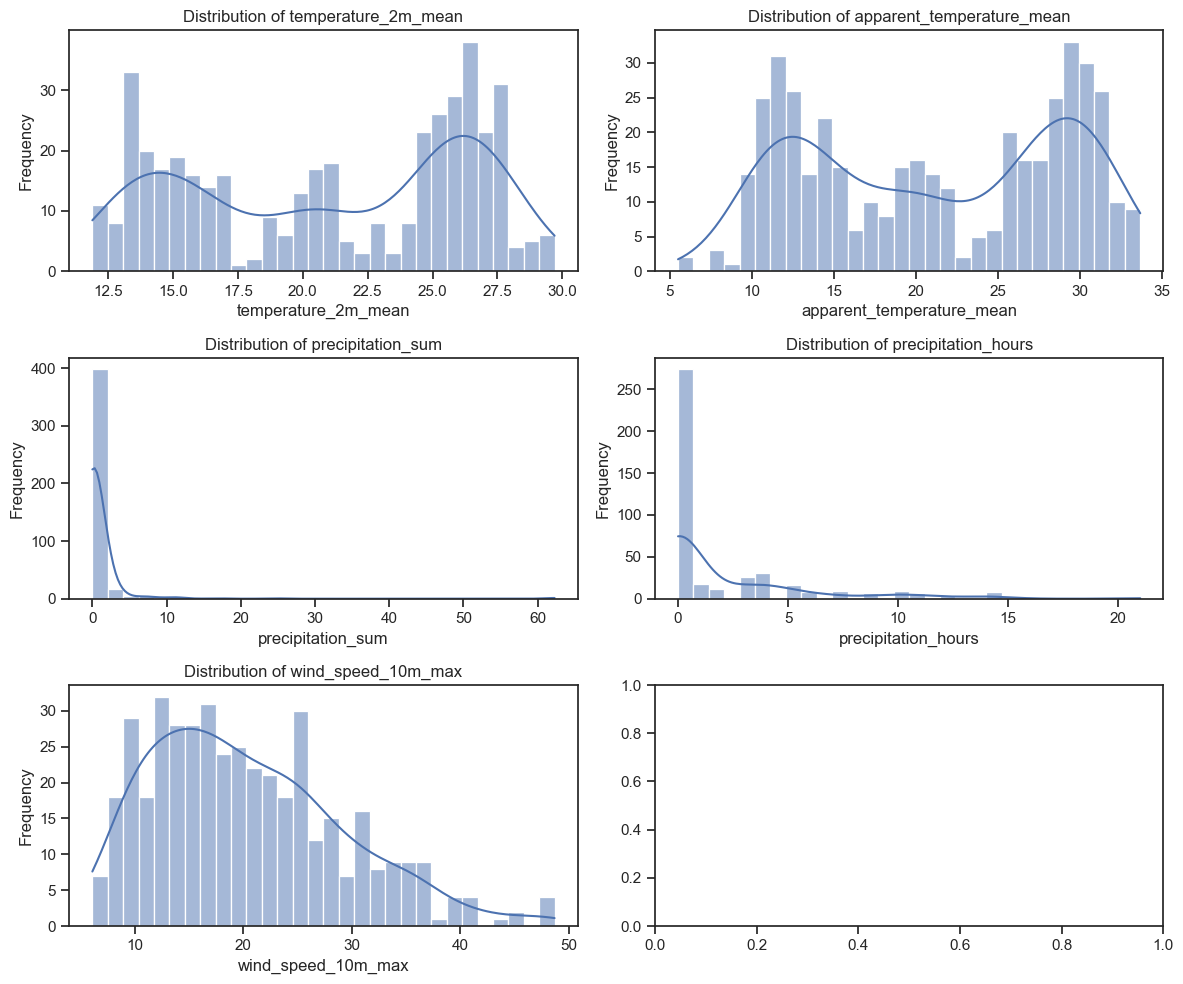

In [73]:
## Continues Columns for a Histogram Plot
continuous_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "precipitation_sum",
    "precipitation_hours",
    "wind_speed_10m_max",
]

#Initialize the 2x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes = axes.flatten()

#Loop through your columns and assign each to an axis
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])

    # Use axes[i] to set titles and labels for each specific subplot
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout() #Makes it look pretty
plt.show()

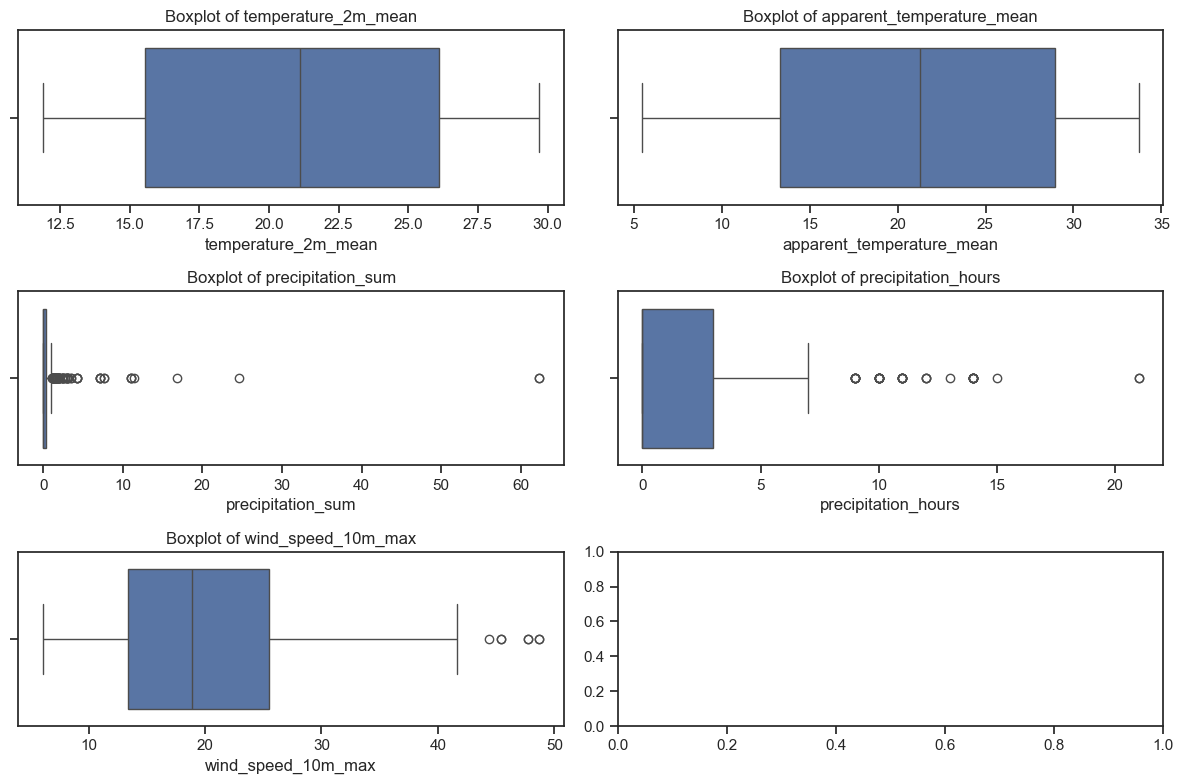

In [74]:
#Initialize the 2x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

axes = axes.flatten()

#Loop through your columns and assign each to an axis
for i, col in enumerate(continuous_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    
    # Use axes[i] to set titles and labels for each specific subplot
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

plt.tight_layout() #Makes it look pretty
plt.show()

In [75]:
df[continuous_cols].agg(["skew", "kurtosis"]).T 

,skew,kurtosis
temperature_2m_mean,-0.1968,-1.4981
apparent_temperature_mean,-0.0801,-1.5023
precipitation_sum,11.1126,139.5873
precipitation_hours,2.2023,5.0902
wind_speed_10m_max,0.7379,0.1493


### Continuous Analysis  

`temperature_2m_mean` & `apparent_temperature_mean`: The graph distribution is bi-nomial distribution, indicating the season tempreture patterns experienced in Malta. The strongly negative kurtosis shows a flat distribution with light tails, suggesting stable temperatures and very few extreme values.

`precipitation_sum`: The graph distribution is extremely right-skewed, showing that most days have little or no precipitation while a small number of days experience high amounts of rainfall. The exceptionally high kurtosis indicates heavy tails and the presence of extreme outliers, showcasing strong non-normality.

`wind_speed_10m_max`: The graph distribution shows moderate right skewness, meaning higher wind speeds occur less frequently but are present. Kurtosis is close to zero, suggesting a distribution not far from normal with limited extreme wind events.

`precipitation_hours`: The graph distribution is strongly right-skewed, indicating many days with few or no hours of rain and fewer days with prolonged rainfall. The high kurtosis reflects heavy tails and occasional long-duration rain events, making the distribution notably non-normal.

**Conclusion:** The temperature features are well-distributed for most ML algorithms; however, the high skewness and outlier density in the precipitation and wind features suggest that tree-based models or targeted feature engineering will be essential to handle the non-normal variance and extreme values effectively.

### Discrete Columns

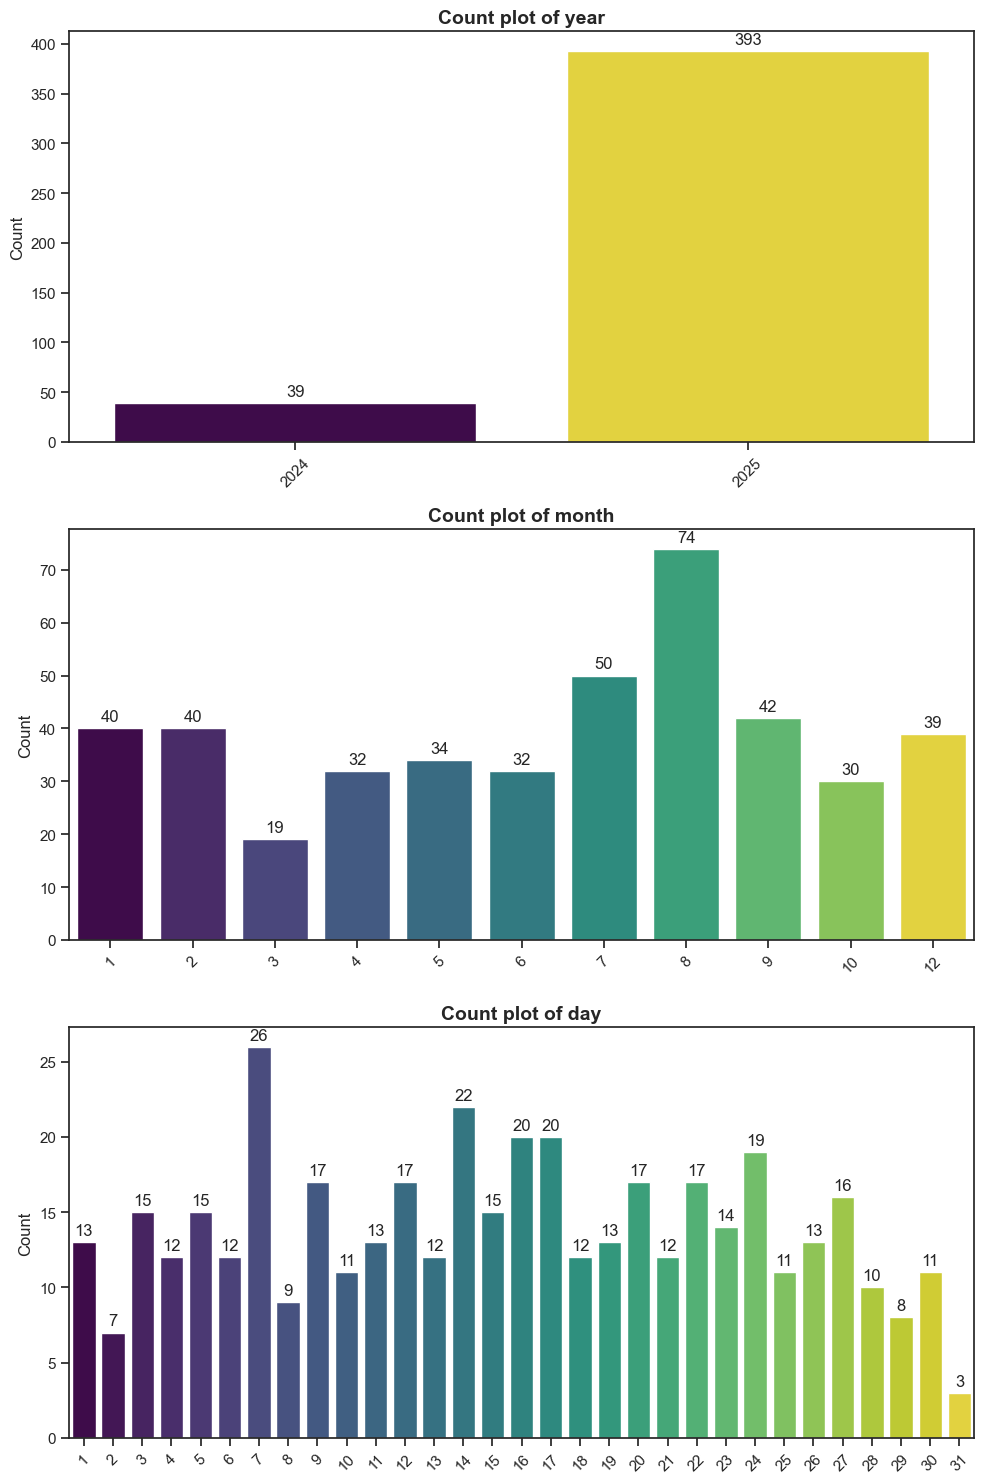

In [76]:
discrete_cols = ["year", "month", "day"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

for i, col in enumerate(discrete_cols):
    ax = axes[i]
    
    sns.countplot(
        x=col, 
        data=df, 
        hue=col, 
        legend=False, 
        ax=ax, 
        palette="viridis"
    )
    
    #Loop through all containers to add labels to every bar
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    
    # Formatting
    ax.set_title(f"Count plot of {col}", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel("") 
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Discrete Analysis

From the data count, shows the `year` is heavily skewed towards the most recent year, combined with the low Standard Deviation the value should be disregarded as it is nearly a constant value.


The `month` feature shows a bi-nomial distribution with two peaks around the Summer months and around the Winter Months (December, Janauary and February). It shows a significant peak around August. 

The `Day` plot shows spikes roughly every 7 days (7th, 14th, 21). This might indicate a weekly rhythm, it further supports that this feature should be changed to show the days of the week instead. 

### Binary Columns

In [77]:
#Place the binary features from the dataset in array
binary_cols = [
    "is_holiday",
    "tag_National",
    "tag_Accident",
    "tag_Traffic",
    "tag_Police",
    "tag_Transport"
]

#Calculate the count and percentage of true values
binary_summary = pd.DataFrame({
    "count": df[binary_cols].sum(),
    "percentage": df[binary_cols].mean() * 100
})

binary_summary

,count,percentage
is_holiday,16,3.7037
tag_National,320,74.0741
tag_Accident,333,77.0833
tag_Traffic,247,57.1759
tag_Police,180,41.6667
tag_Transport,32,7.4074


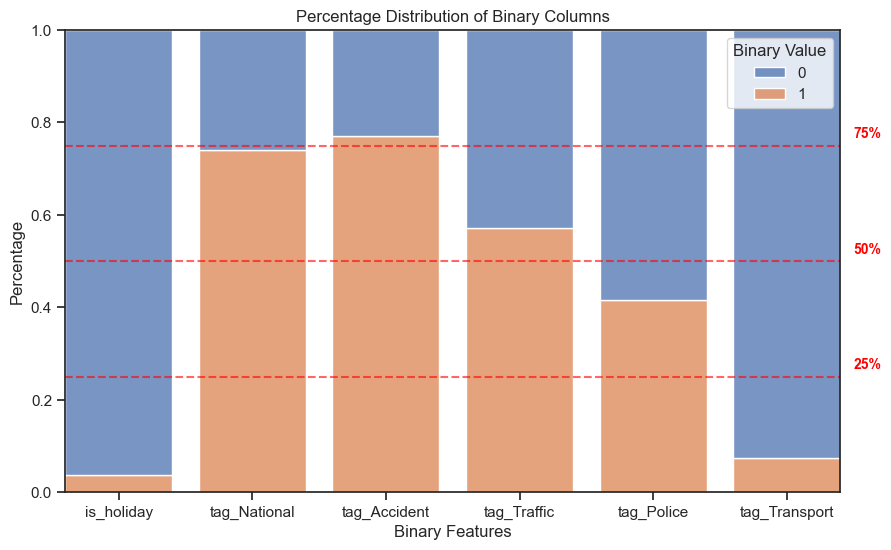

In [78]:
#Reshape the data from wide to long format
df_melted = df[binary_cols].melt(var_name='Column', value_name='Binary Value')

#Plot using a stacked bar chart
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_melted, 
    x='Column', 
    hue='Binary Value', 
    multiple='fill', # This changes the y-axis to percentage (0 to 1.0)
    shrink=0.8
)

#Add dotted lines at 25%, 50%, and 75%
thresholds = [0.25, 0.50, 0.75]
for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    # Adding text label next to the line
    plt.text(x=len(binary_cols)-0.5, y=t+0.01, s=f'{int(t*100)}%', 
             color='red', fontweight='bold', fontsize=10, va='bottom')

plt.title("Percentage Distribution of Binary Columns")
plt.ylabel("Percentage")
plt.xlabel("Binary Features")
plt.show()

### Binary Analysis

The following tags: `tag_National`, `tag_Accident`, `tag_Traffic` and `tag_Police` are high-frequency features which means that the ML models should be able to learn these tags.

The dataset is highly imbalanced for the features `is_holiday` and `tag_Transport`. Techniques like oversampling or specialized loss functions might be required to ensure the model learns to identify these rare events effectively.

### Null Values Analysis

Any `Null` values should have been removed in `1_data_preperation.ipynb`, this is a check to ensure that all the `Null` values were removed.

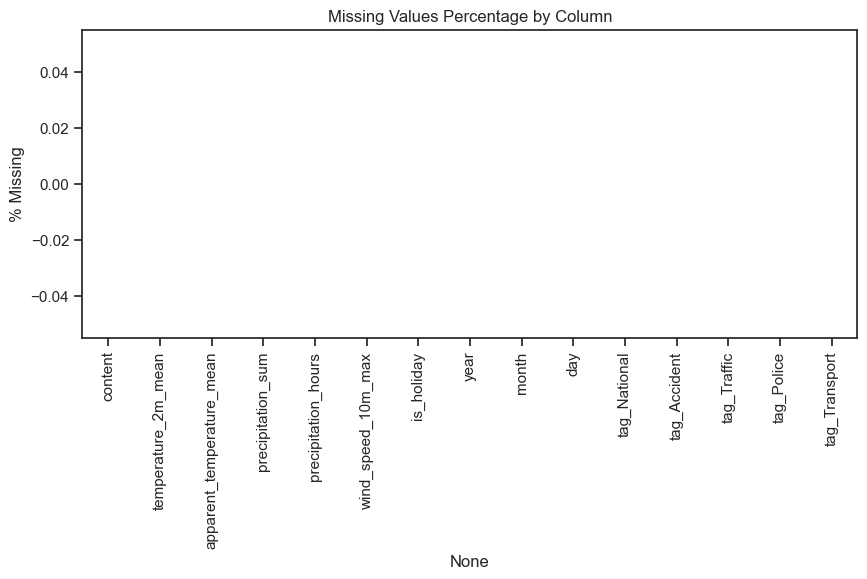

In [79]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values Percentage by Column")
plt.ylabel("% Missing")
plt.show()

In [80]:
summary = []

for col in df.columns:
    summary.append({
        "column": col,
        "dtype": df[col].dtype,
        "missing_%": df[col].isna().mean() * 100,
        "unique": df[col].nunique(),
        "mean": df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else None,
        "std": df[col].std() if pd.api.types.is_numeric_dtype(df[col]) else None,
        "min": df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None,
        "max": df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None
    })

summarised_df = pd.DataFrame(summary)
summarised_df

,column,dtype,missing_%,unique,mean,std,min,max
0,content,object,0.0000,432,NaN,NaN,NaN,NaN
1,temperature_2m_mean,float64,0.0000,110,21.0218,5.4344,11.9000,29.7000
2,apparent_temperature_mean,float64,0.0000,142,21.2241,7.8456,5.5000,33.7000
3,precipitation_sum,float64,0.0000,34,0.9692,4.6657,0.0000,62.3000
4,precipitation_hours,int64,0.0000,16,2.0440,3.6399,0.0000,21.0000
5,wind_speed_10m_max,float64,0.0000,148,20.3815,8.8227,6.1000,48.7000
6,is_holiday,int64,0.0000,2,0.0370,0.1891,0.0000,1.0000
7,year,int64,0.0000,2,2024.9097,0.2869,2024.0000,2025.0000
8,month,int64,0.0000,11,6.3773,3.2382,1.0000,12.0000
9,day,int64,0.0000,31,15.4329,8.2276,1.0000,31.0000


### Content - Univariate anaylsis

In [81]:
# Check the first few rows to make sure the 'not defined' warning can be ignored, and the actual dataset is imported correctly.
print(Finalized_Dataset['content'].head())

vectorizer = vectFunc()

X_tfidf = vectorizer.fit_transform(Finalized_Dataset['content'])

 #   Make sure shape and num of features are the same for each developer:
 #   Shape: 432,10,000
 #Features: 1000
print("\nShape of TF-IDF matrix:", X_tfidf.shape)
print("Number of features:", len(vectorizer.vocabulary_))

0    Collision between a car and a motorbike in Żur...
1    Car-motorcycle traffic accident Yesterday, at ...
2    Car-motorcycle collision in Ħal Qormi Today, a...
3    Collision between motorcycle and car in Għaxaq...
4    Car-motorcycle collision Yesterday, at around ...
Name: content, dtype: object

Shape of TF-IDF matrix: (432, 1000)
Number of features: 1000


In [82]:
#Sum TF-IDF scores for each word across all documents
weights = X_tfidf.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

#Create a dataFrame for easy sorting and displaying for graphy
df_weights = pd.DataFrame({'word': words, 'weight': weights})
df_weights = df_weights.sort_values(by='weight', ascending=False)

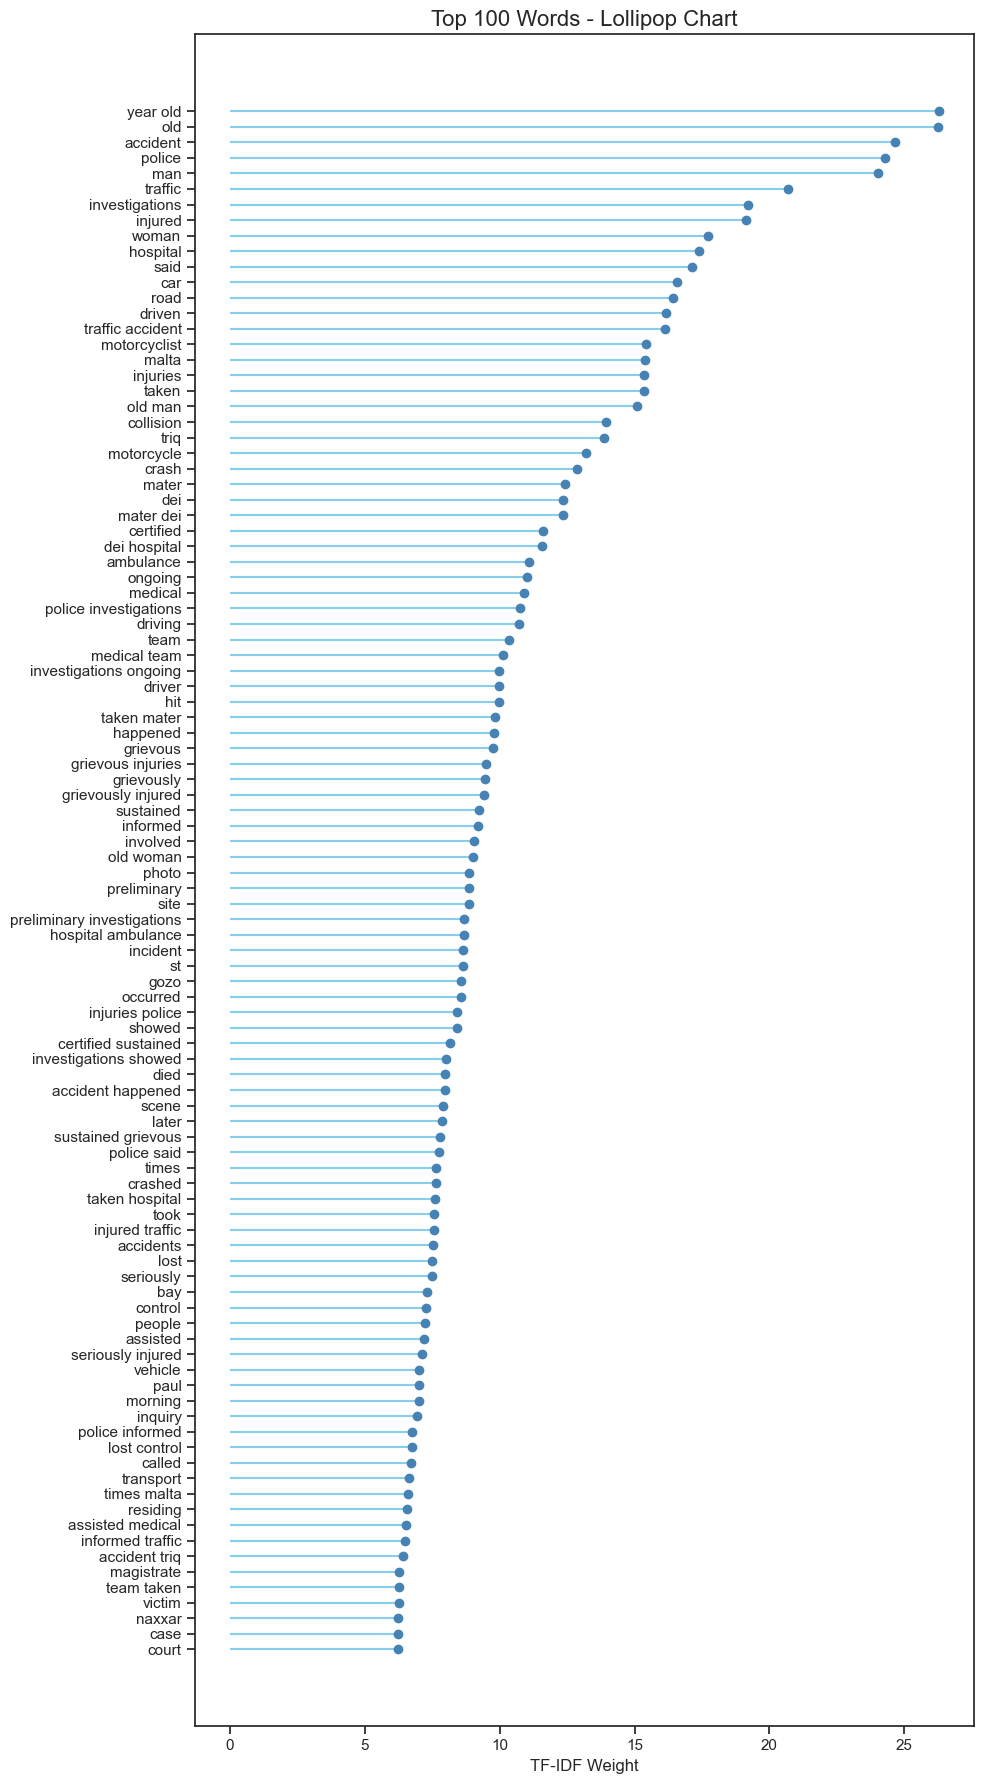

In [83]:
# Uses A lollipop Chart to display the top 100 weighted words found in the vectorised data
plt.figure(figsize=(10, 18))

# Draw lines and dots
plt.hlines(y=df_weights['word'][:100], xmin=0, xmax=df_weights['weight'][:100], color='skyblue')
plt.plot(df_weights['weight'][:100], df_weights['word'][:100], "o", color='steelblue')

plt.title("Top 100 Words - Lollipop Chart", fontsize=16)
plt.xlabel("TF-IDF Weight")
plt.gca().invert_yaxis() # Highest weighted value at the top
plt.tight_layout()
plt.show()

In [84]:
# Check how many documents contain each word (Binary count)
doc_freq = (X_tfidf > 0).sum(axis=0).A1
df_doc_freq = pd.DataFrame({'word': words, 'doc_count': doc_freq})

# Show words that appear in more than 40% of the articles
threshold = X_tfidf.shape[0] * 0.4
common_words = df_doc_freq[df_doc_freq['doc_count'] > threshold]
common_words_sorted = common_words.sort_values(by='doc_count', ascending=False)
print(f"Words appearing in over 40% of docs: {len(common_words_sorted)}")
print(common_words_sorted)

Words appearing in over 40% of docs: 25
               word  doc_count
712          police        334
660             old        325
987        year old        320
76         accident        307
569             man        263
921         traffic        259
427        hospital        257
475        injuries        226
699           photo        220
799            said        218
494  investigations        211
471         injured        210
580           mater        208
286             dei        208
581       mater dei        208
311          driven        206
933            triq        201
287    dei hospital        193
564           malta        190
663         old man        186
666         ongoing        183
782            road        183
890           taken        182
203       certified        178
183             car        176


### Content Univariate findings

**Univariate Analysis Findings**

Analysis of the top 100 words by TF-IDF weight revealed three primary thematic clusters:

Injury Related Features: "injured", "hosipital", "injuries", "mater dei", "ambulance", "medical", "medical team", "grievous injuries", "grievous injured", "grievously", "injuries police", "died", "seriously injured", "assisted medical", "victim".

Accident & Traffic related Features: "accident", "traffic", "collision", "crash", "police investigations", "hit","investigations ongoing", "hospital ambulance", "lost control".

Possibly important Features: "magistrate", "car", "motorcylist".

**High-Frequency Observations (Features in >40% of Articles)**

Analysis of the most common recurring features yielded the following insights:

**Standardized Reporting:** The high prevalence of "police," "accident," and "years old" aligns with the structured nature of official police releases and journalistic reports on traffic incidents.

**Medical Priority:** A majority of articles prioritize the victim's status, frequently mentioning "Mater Dei" (the primary acute-care hospital in Malta) and specific injury descriptors. The remaining frequent terms largely detail the nature of the collision and the parties involved.

<hr>

## Bivariate Analysis

### Analysis of the article content & the tags

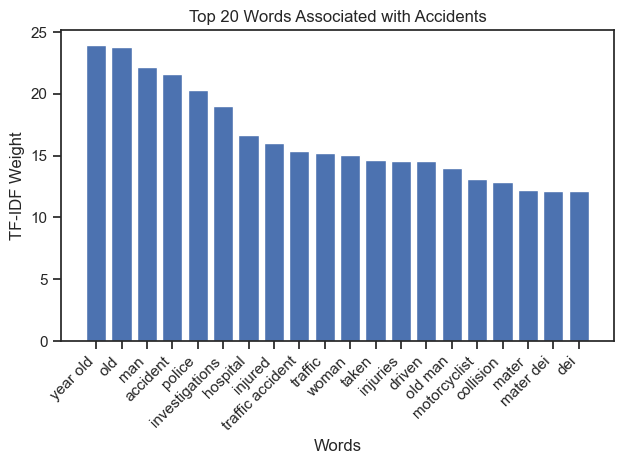

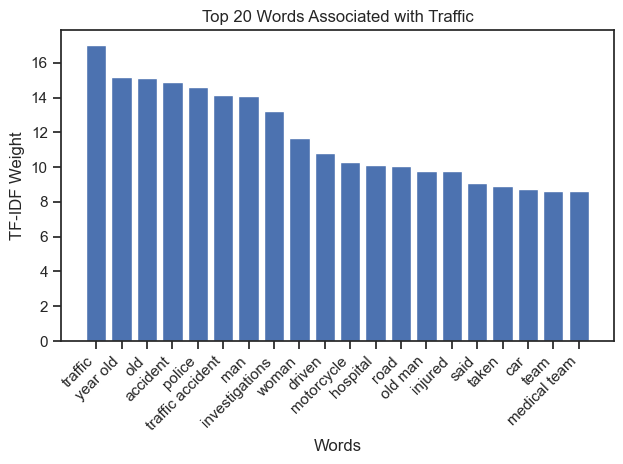

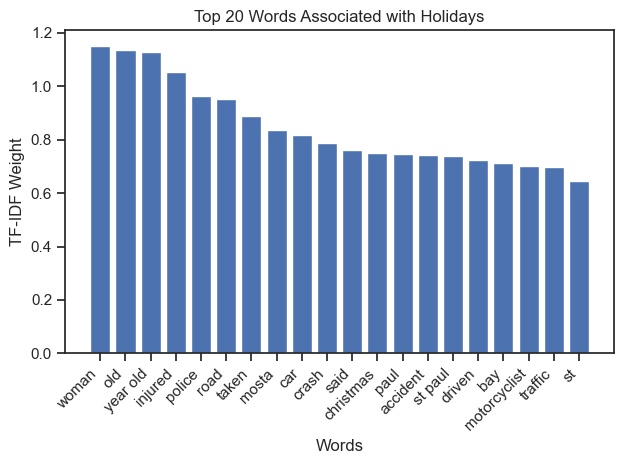

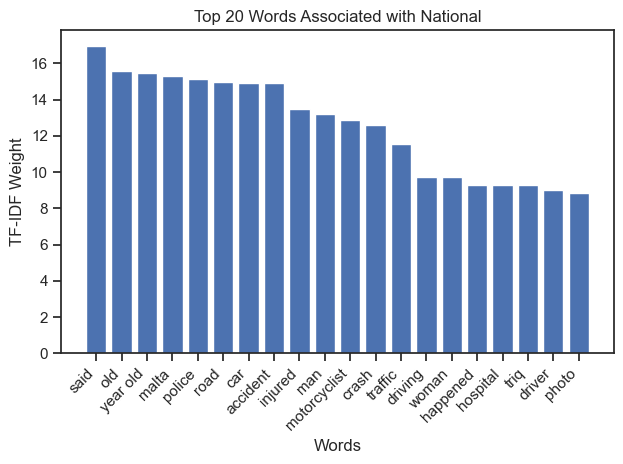

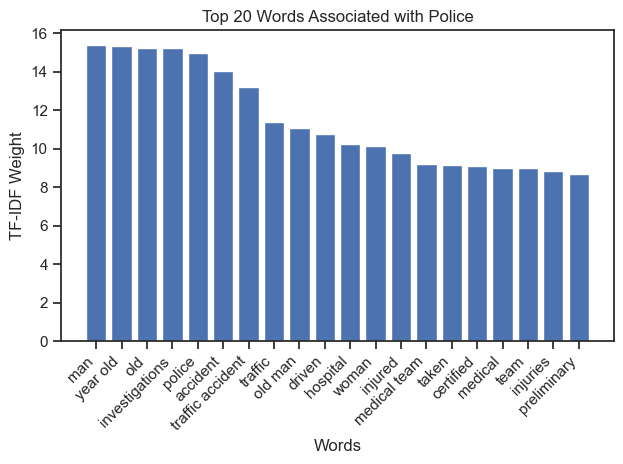

In [85]:
# Dictionary of tags and their corresponding indices
tag_indices = {
    "Accidents": Finalized_Dataset[Finalized_Dataset['tag_Accident'] == 1].index,
    "Traffic": Finalized_Dataset[Finalized_Dataset['tag_Traffic'] == 1].index,
    "Holidays": Finalized_Dataset[Finalized_Dataset['is_holiday'] == 1].index,
    "National": Finalized_Dataset[Finalized_Dataset['tag_National'] == 1].index,
    "Police": Finalized_Dataset[Finalized_Dataset['tag_Police'] == 1].index
}

words = vectorizer.get_feature_names_out()

# Loop through each tag and plot a separate figure
for tag_name, indices in tag_indices.items():
    
    # Filter TF-IDF matrix
    X_subset = X_tfidf[indices]
    
    # Sum TF-IDF weights
    weights = X_subset.sum(axis=0).A1
    
    # Create and sort DataFrame
    df_words = (
        pd.DataFrame({'word': words, 'weight': weights})
        .sort_values(by='weight', ascending=False)
    )
    
    # Select top 20
    top_20 = df_words.head(20)
    
    # Plot
    plt.figure()
    plt.bar(top_20['word'], top_20['weight'])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Words')
    plt.ylabel('TF-IDF Weight')
    plt.title(f'Top 20 Words Associated with {tag_name}')
    plt.tight_layout()
    plt.show()


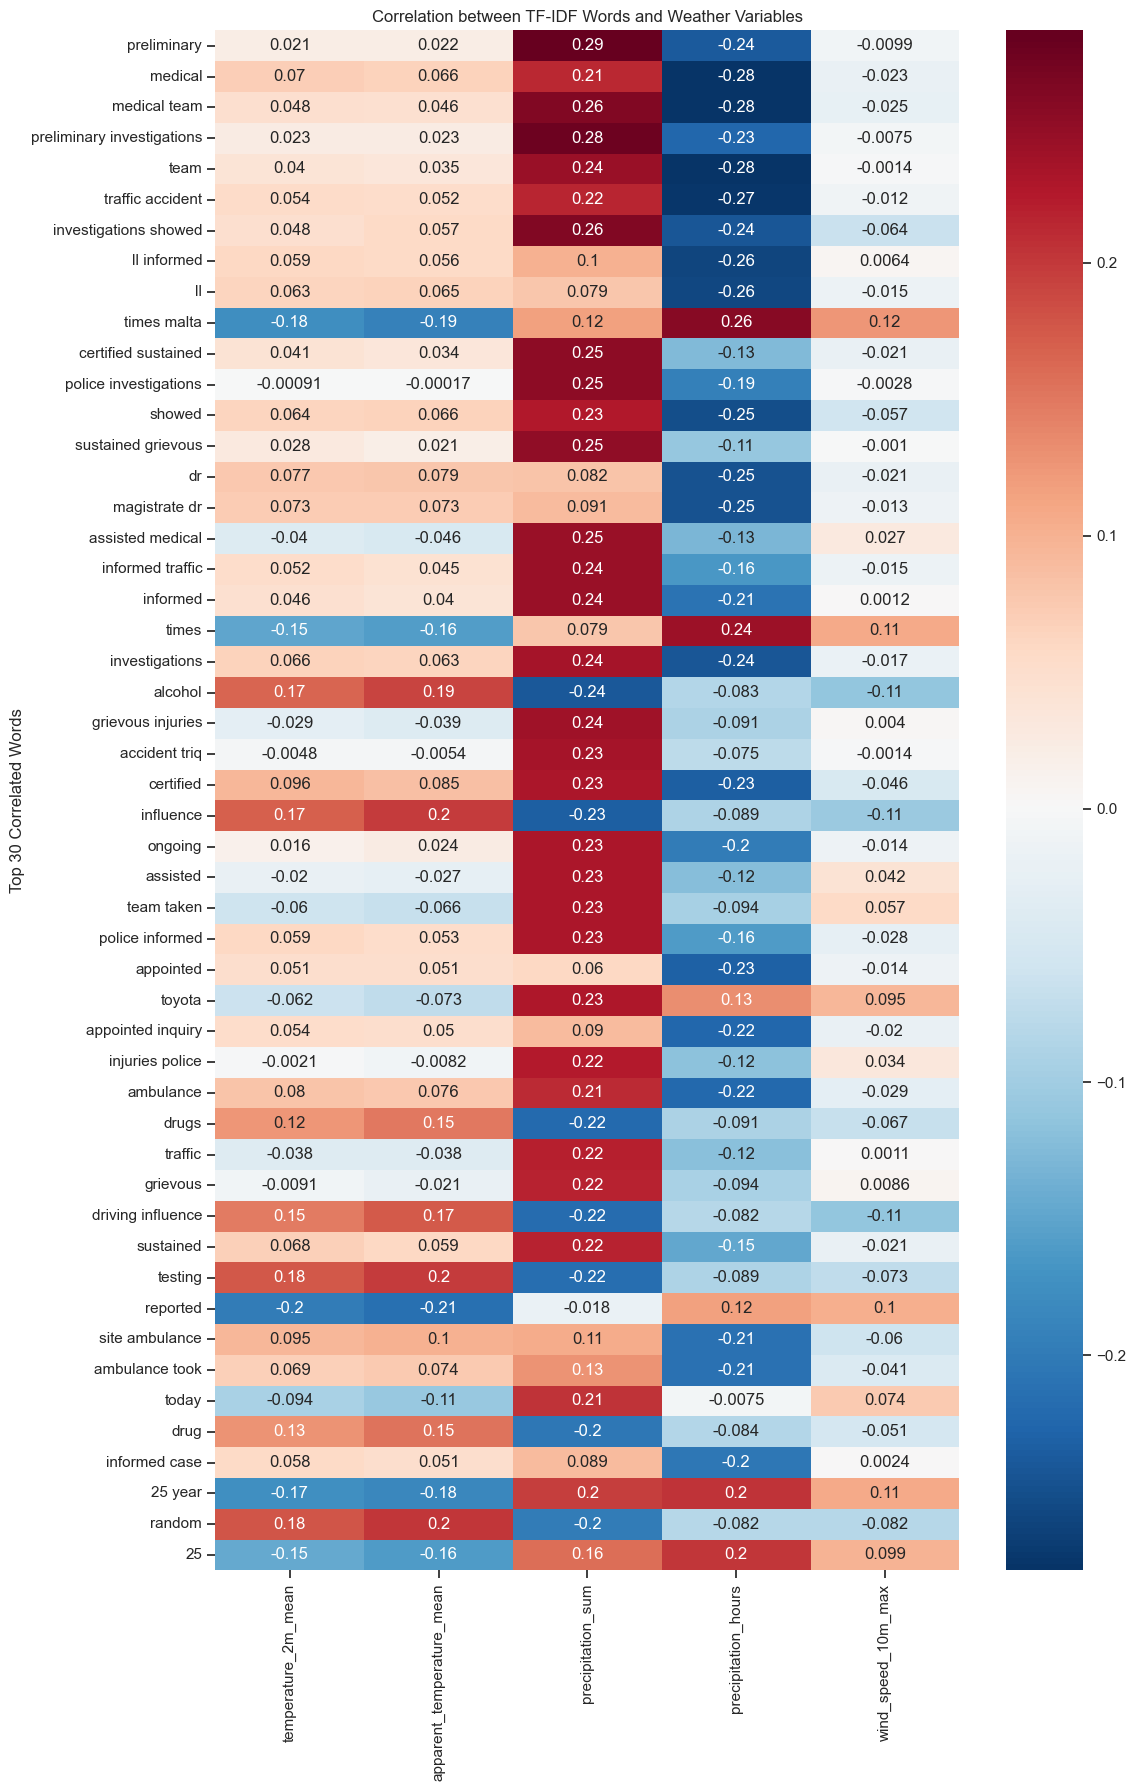

In [86]:
#Define the targets
continuous_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "precipitation_sum",
    "precipitation_hours",
    "wind_speed_10m_max",
]

all_correlations = {}

#Calculate correlations for each continuous variable
for col in continuous_cols:
    target_values = Finalized_Dataset[col].values
    col_corrs = []
    
    for i in range(X_tfidf.shape[1]):
        # Get TF-IDF scores for the specific word
        word_scores = X_tfidf[:, i].toarray().flatten()
        # Spearman correlation
        corr, _ = spearmanr(word_scores, target_values)
        col_corrs.append(corr)
    
    all_correlations[col] = col_corrs

#Creates a DF for visulation
df_corr_matrix = pd.DataFrame(all_correlations, index=words)

# Take the top 30 words with highest absolute correlation across any column
df_corr_matrix['max_abs_corr'] = df_corr_matrix.abs().max(axis=1)
top_words = df_corr_matrix.sort_values(by='max_abs_corr', ascending=False).head(50)
top_words = top_words.drop(columns=['max_abs_corr'])

#Plot the heat map
plt.figure(figsize=(12, 20))
sns.heatmap(top_words, annot=True, cmap='RdBu_r', center=0)
plt.title("Correlation between TF-IDF Words and Weather Variables")
plt.ylabel("Top 30 Correlated Words")
plt.show()

In [87]:
# Print top correlations
print("Top 20 words correlated with temperature_2m_mean:")
print(df_corr_matrix['temperature_2m_mean'].sort_values(ascending=False).head(20).to_string())

print("\nTop 20 words correlated with apparent_temperature_mean:")
print(df_corr_matrix['apparent_temperature_mean'].sort_values(ascending=False).head(20).to_string())

print("\nTop 20 words correlated with precipitation_sum:")
print(df_corr_matrix['precipitation_sum'].sort_values(ascending=False).head(20).to_string())

print("\nTop 20 words correlated with precipitation_hours:")
print(df_corr_matrix['precipitation_hours'].sort_values(ascending=False).head(20).to_string())

print("\nTop 20 words correlated with wind_speed_10m_max:")
print(df_corr_matrix['wind_speed_10m_max'].sort_values(ascending=False).head(20).to_string())

Top 20 words correlated with temperature_2m_mean:
arrested            0.2010
june                0.1896
42                  0.1852
random              0.1783
food courier        0.1765
testing             0.1755
courier             0.1747
influence           0.1702
nepal               0.1693
scene               0.1668
alcohol             0.1658
known               0.1624
association         0.1600
drink               0.1593
food                0.1585
emergency           0.1580
pun                 0.1575
khim                0.1574
cctv                0.1507
driving influence   0.1482

Top 20 words correlated with apparent_temperature_mean:
random              0.2034
testing             0.1985
influence           0.1972
alcohol             0.1925
arrested            0.1913
june                0.1855
food courier        0.1835
association         0.1755
driving influence   0.1744
courier             0.1742
nepal               0.1713
drink               0.1669
food                0.1656
kh

In [88]:
# Print worst correlations for a specific variable as requested before
print("Bottom 20 words correlated with temperature_2m_mean:")
print(df_corr_matrix['temperature_2m_mean'].sort_values(ascending=False).tail(20).to_string())

print("\nBottom 20 words correlated with apparent_temperature_mean:")
print(df_corr_matrix['apparent_temperature_mean'].sort_values(ascending=False).tail(20).to_string())

print("\nBottom 20 words correlated with precipitation_sum:")
print(df_corr_matrix['precipitation_sum'].sort_values(ascending=False).tail(20).to_string())

print("\nBottom 20 words correlated with precipitation_hours:")
print(df_corr_matrix['precipitation_hours'].sort_values(ascending=False).tail(20).to_string())

print("\nBottom 20 words correlated with wind_speed_10m_max:")
print(df_corr_matrix['wind_speed_10m_max'].sort_values(ascending=False).tail(20).to_string())

Bottom 20 words correlated with temperature_2m_mean:
neidhardt              -0.1359
asger                  -0.1359
bay bypass             -0.1366
yamaha                 -0.1380
police investigating   -0.1403
attard                 -0.1407
christmas              -0.1431
25                     -0.1456
photo times            -0.1468
bypass                 -0.1477
times                  -0.1490
rushed                 -0.1577
investigating          -0.1592
days                   -0.1639
december               -0.1740
25 year                -0.1749
times malta            -0.1772
ongoing file           -0.1782
accident reported      -0.1839
reported               -0.1979

Bottom 20 words correlated with apparent_temperature_mean:
attard                 -0.1340
bay bypass             -0.1345
police investigating   -0.1368
alejandro              -0.1372
brincat                -0.1373
christmas              -0.1431
yamaha                 -0.1451
photo times            -0.1524
investigating      

#### Content Features - Bivariate Analysis Findings



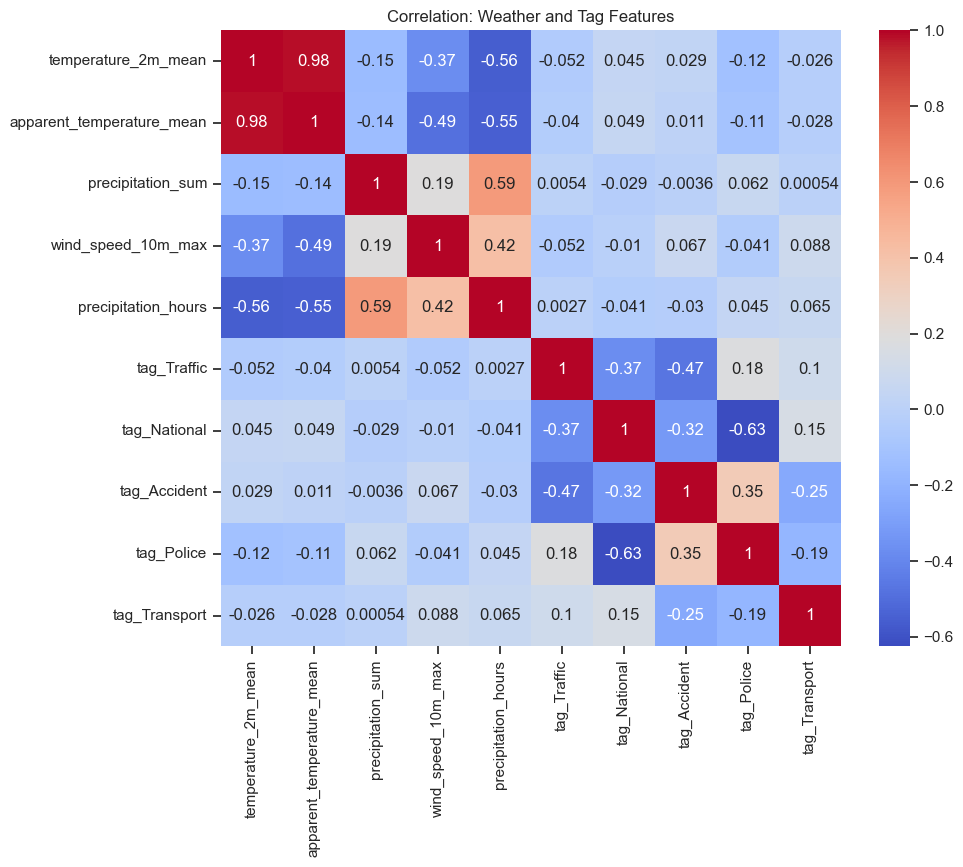

In [89]:
plt.figure(figsize=(10, 8))

#Matrix of Correlation between all the continues features and binary features
corr = df[["temperature_2m_mean", "apparent_temperature_mean", "precipitation_sum", "wind_speed_10m_max",
           "precipitation_hours","tag_Traffic", "tag_National", "tag_Accident","tag_Police","tag_Transport"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Weather and Tag Features")
plt.show()

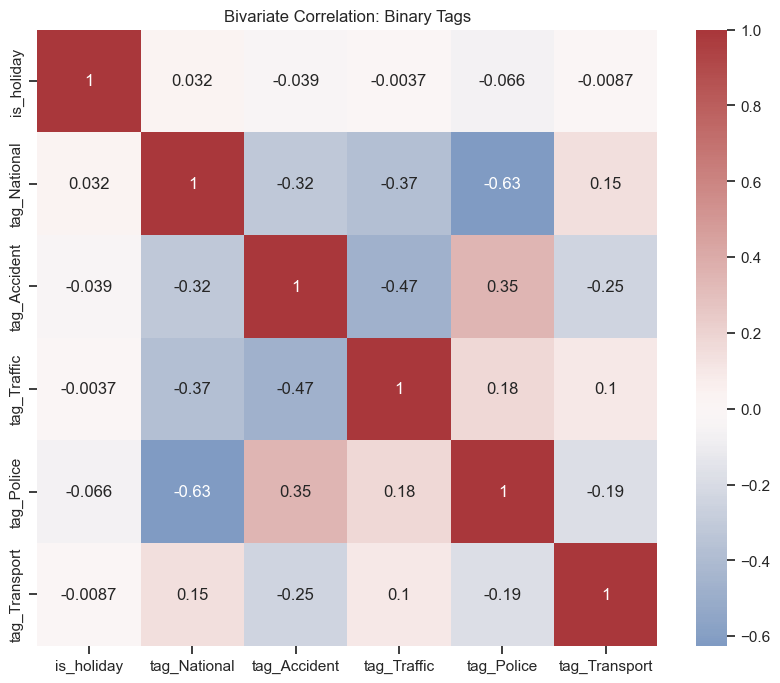

In [90]:
#List of your binary columns
binary_cols = ["is_holiday", "tag_National", "tag_Accident", 
               "tag_Traffic", "tag_Police", "tag_Transport"]

#Calculate the correlation matrix
binary_corr = df[binary_cols].corr()

#Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(binary_corr, annot=True, cmap='vlag', center=0)
plt.title("Bivariate Correlation: Binary Tags")
plt.show()

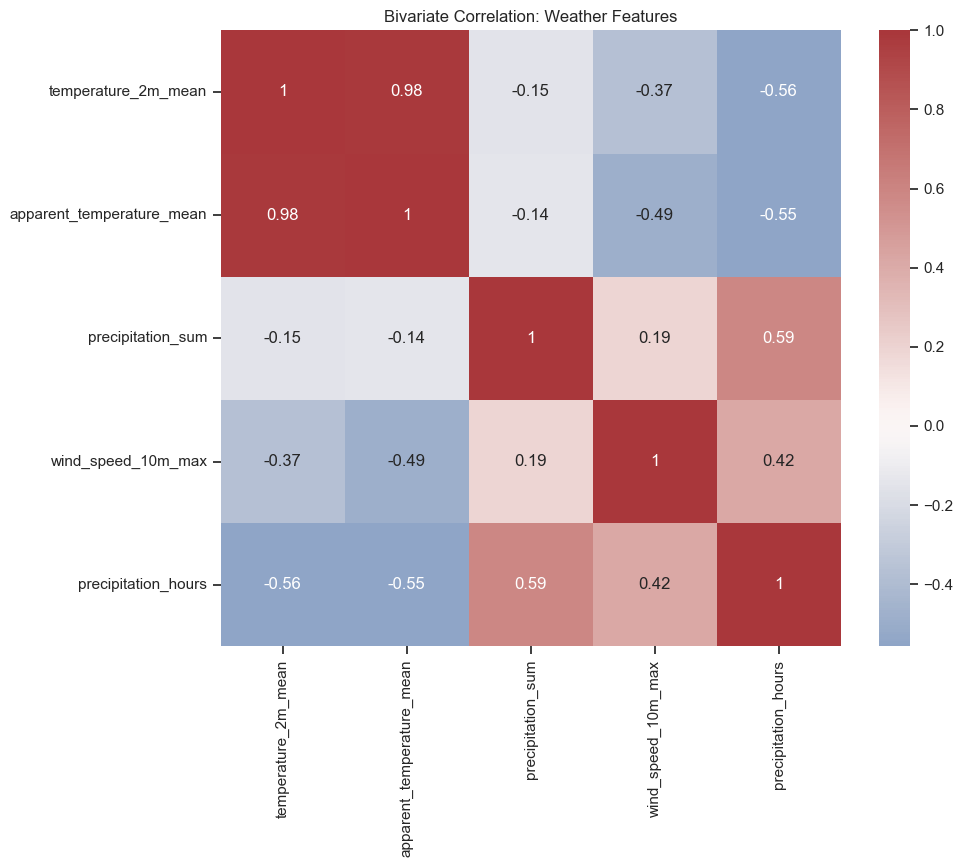

In [91]:
# List of your binary columns
weather_cols = ["temperature_2m_mean", "apparent_temperature_mean", "precipitation_sum", "wind_speed_10m_max",
           "precipitation_hours"]

# Calculate the correlation matrix
weather_cols = df[weather_cols].corr()

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(weather_cols, annot=True, cmap='vlag', center=0)
plt.title("Bivariate Correlation: Weather Features")
plt.show()

## Correlation Matrix Analysis

The correlation matrix highlights several strong relationships between features. The most prominent positive correlation is between `mean_2m_temperature` and `mean_apparent_temperature` (≈ 0.98), indicating these variables capture nearly the same thermal signal and one of them can be made redundant. 

Among weather variables, precipitation hours shows a moderate positive correlation with `precipitation_sum` (≈ 0.59) and `wind_speed_10_max` (≈ 0.42), suggesting wetter days tend to be longer-lasting and windier.

In contrast, temperature is moderately negatively correlated with `precipitation_hours` (≈ −0.55 to −0.56), implying cooler Winter periods are associated with more frequent or longer rainfall. 

For tag features, the strongest relationships are negative: `tag_National` and `tag_Police` exhibit a strong negative correlation (≈ −0.63), while `tag_Traffic` is negatively correlated with both `tag_Accident` (≈ −0.47) and `tag_National` (≈ −0.37). 

Overall, weather variables show clearer interdependencies with each other, whereas tag variables mainly exhibit mutual exclusivity rather than strong links to weather conditions.

### BiVariate Analysis Conclusion




These weather features are likely not the primary drivers for the "Traffic" or "Accident" tags in this specific dataset. Other factors, such as time of day, road type, or driver behavior, likely carry more predictive weight.

| Weather |Correlation with Accident|Visual Observation|
| ------------- | ---- | -------------- |
|Precipitation|-0.017 (Negligible)|Overlapping distributions; most data at 0 mm.|
|Temperature|0.055 (Negligible)|Boxplots of accidents slightly higher in higher tempratures.|
|Wind Speed|0.066 (Negligible)|Distributions follow the same shape and peak.|

## Multivariate Analysis

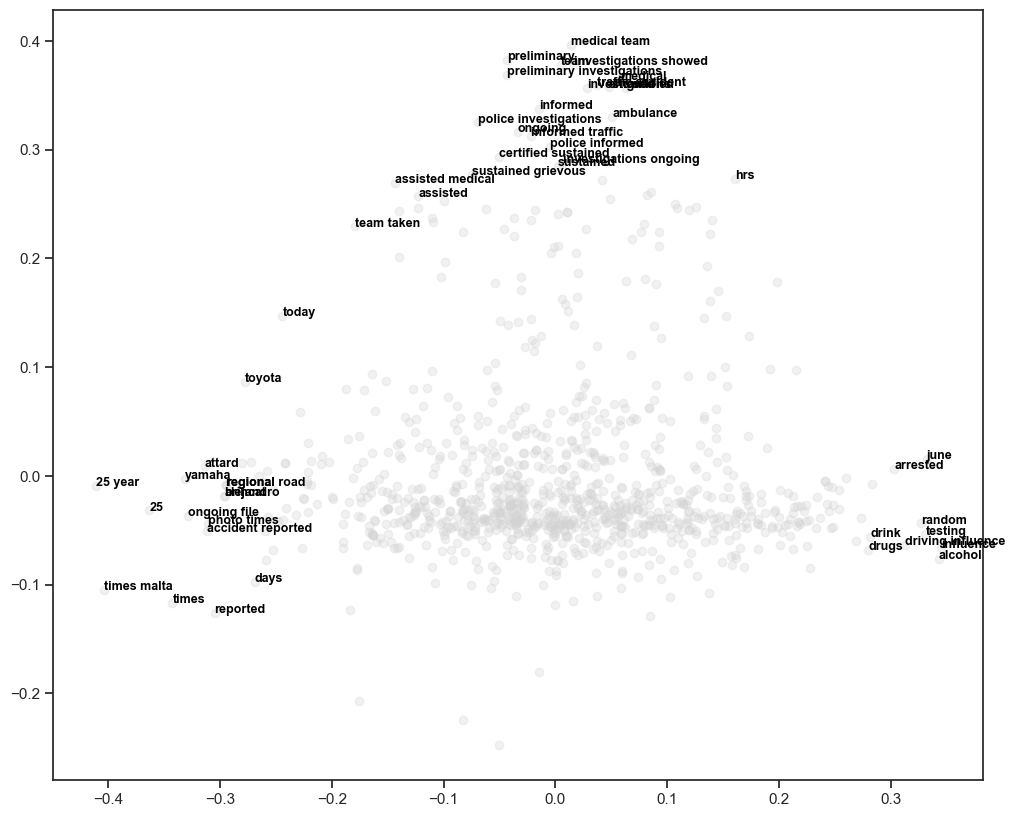

In [92]:
from sklearn.decomposition import PCA

# Drop the 'max_abs_corr' if you haven't already
data_for_pca = df_corr_matrix.drop(columns=['max_abs_corr'], errors='ignore') #df_corr_matrix - Used in the 

pca = PCA(n_components=2)
components = pca.fit_transform(data_for_pca)

# Create the scatter plot as usual
plt.figure(figsize=(12, 10))
plt.scatter(components[:, 0], components[:, 1], alpha=0.3, c='lightgray')

# Only label words that are in the top 10% of distance from the origin
distances = np.sqrt(components[:, 0]**2 + components[:, 1]**2)
threshold = np.percentile(distances, 95) # Top 5% furthest words

for i, word in enumerate(data_for_pca.index):
    if distances[i] > threshold:
        plt.annotate(word, (components[i, 0], components[i, 1]), 
                     fontsize=9, weight='bold', color='black')

### Multivariate Conclusion 

The position of the words describe pattern that can be found in article data:

**Injury and Medical** Cluster (Top): Words like "medical team," "preliminary investigations," "ambulance," and "police informed" are clustered at the top. These words represents the severity of the accident that could have occured.

**Incident Specifics** Cluster (Right): On the far right, you see a clear grouping of "arrested," "drink," "drugs," "driving influence," and "alcohol." This indicates a specific subset of reports focused on what could have caused the accidents. 

**Common accoring words** Cluster (Left): This area contains specific details like vehicle brands ("toyota," "yamaha"), locations ("regional road," "attard"), and demographics ("25 year"). Points here likely represent common words that are associated with a most of the accidents.

The **Generic/Reporting** Center: The dense cloud of grey dots in the middle represents the "average" vocabulary used across most reports—words that are common but not distinct enough to be pulled toward one of the specific thematic corners

# After Fixes

### Cyclic features breakdown

In [93]:
#Import the Finalised dataset from step 1
df_final = pd.read_csv("Datasets/Finalized_Dataset.csv", sep=",", header=0)
print(df_final.head(5)) # Display the head

                                             content  temperature_2m_mean  \
0  Collision between a car and a motorbike in Żur...               0.1155   
1  Car-motorcycle traffic accident Yesterday, at ...               0.7101   
2  Car-motorcycle collision in Ħal Qormi Today, a...              -0.0331   
3  Collision between motorcycle and car in Għaxaq...               0.8401   
4  Car-motorcycle collision Yesterday, at around ...              -1.0550   

   apparent_temperature_mean  precipitation_sum  precipitation_hours  \
0                     0.1487            -0.2042              -0.5798   
1                     0.8776            -0.1546               0.1515   
2                    -0.0075            -0.2042              -0.5798   
3                     0.7344            -0.2042              -0.5798   
4                    -1.0228             0.0601               0.3953   

   wind_speed_10m_max  is_holiday  month  tag_National  tag_Accident  \
0             -1.2586           

In [94]:
def decode_dow(df_final, sin_col="dow_sin", cos_col="dow_cos"):
    sin = df_final[sin_col]
    cos = df_final[cos_col]

    norm = np.sqrt(sin**2 + cos**2)
    sin /= norm
    cos /= norm

    angle = np.mod(np.arctan2(sin, cos), 2 * np.pi)
    day = np.round(7 * angle / (2 * np.pi)).astype(int)
    day = day.replace(0, 7)

    names = {
        1: "Monday", 2: "Tuesday", 3: "Wednesday",
        4: "Thursday", 5: "Friday",
        6: "Saturday", 7: "Sunday"
    }

    df["dow_num"] = day
    df["dow_name"] = day.map(names)

    return df

df_final = decode_dow(df_final)

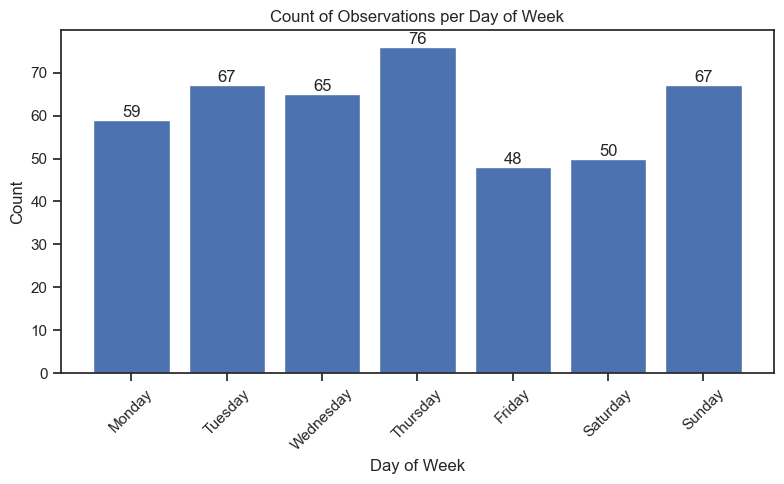

In [95]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = (
    df_final["dow_name"]
    .value_counts()
    .reindex(day_order, fill_value=0)
)

plt.figure(figsize=(8, 5))
bars = plt.bar(day_counts.index, day_counts.values)

# Labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.title("Count of Observations per Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [96]:
bivariate_table = df_final.groupby(['month', 'dow_name']).size().unstack(fill_value=0)

# 3. Reorder columns to ensure Monday-Sunday order
bivariate_table = bivariate_table[day_order]

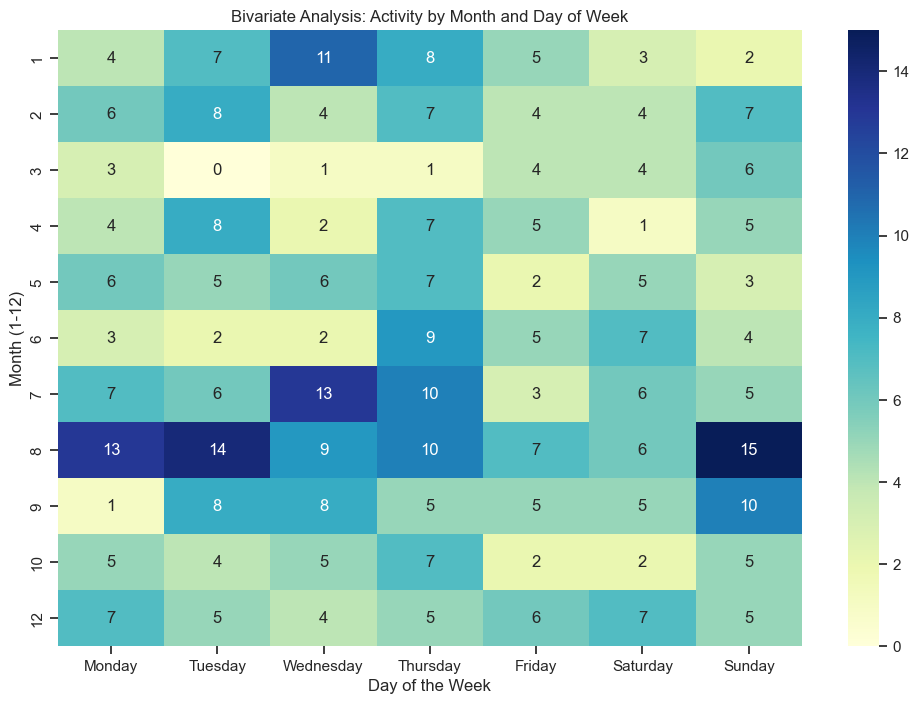

In [97]:
plt.figure(figsize=(12, 8))
sns.heatmap(bivariate_table, annot=True, fmt="d", cmap="YlGnBu")

plt.title('Bivariate Analysis: Activity by Month and Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Month (1-12)')
plt.show()

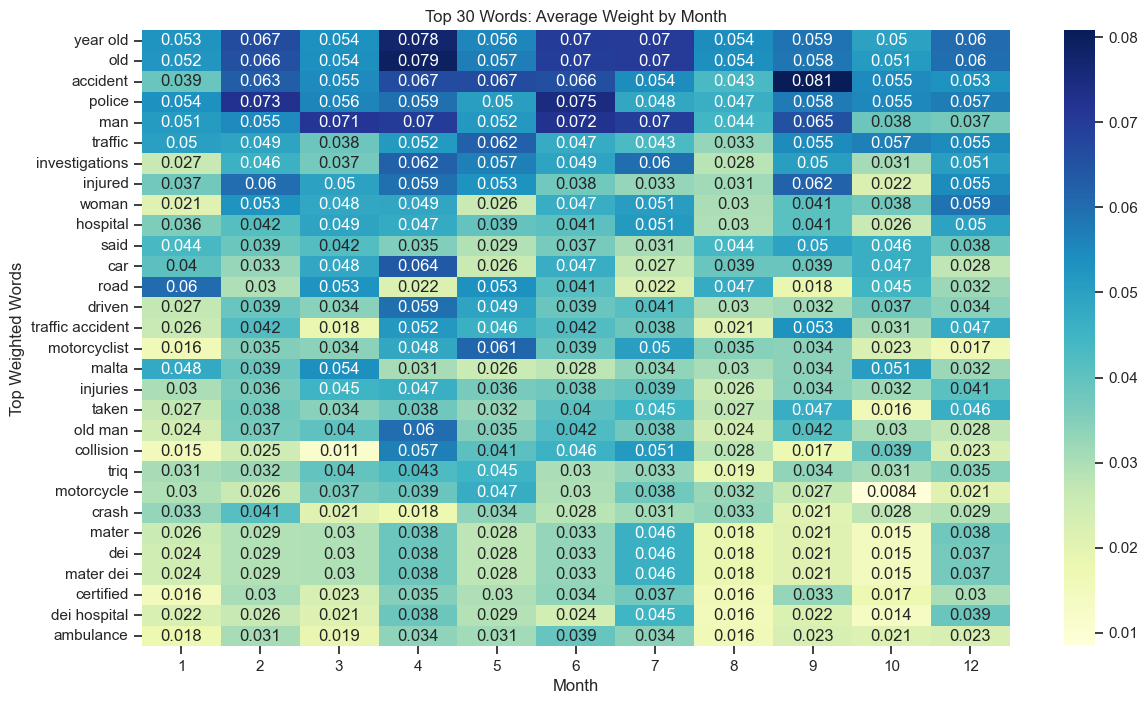

In [98]:
# Get the top 30 most weighted words from your df_weights
top_n = 30
top_words = df_weights.head(top_n)['word'].tolist()

# Find the column indices for these words in the TF-IDF matrix
indices = [vectorizer.vocabulary_[word] for word in top_words]

# Extract scores for just these top words and convert to a DataFrame
df_top_words_scores = pd.DataFrame(
    X_tfidf[:, indices].toarray(), 
    columns=top_words
)

# Combine with your days and months
df_combined = pd.concat([
    df_final[['month', 'dow_name']].reset_index(drop=True), 
    df_top_words_scores
], axis=1)

# Group by Month and calculate the average TF-IDF score for each top word
word_month_analysis = df_combined.groupby('month')[top_words].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(word_month_analysis.T, annot=True, cmap="YlGnBu")
plt.title(f'Top {top_n} Words: Average Weight by Month')
plt.xlabel('Month')
plt.ylabel('Top Weighted Words')
plt.show()

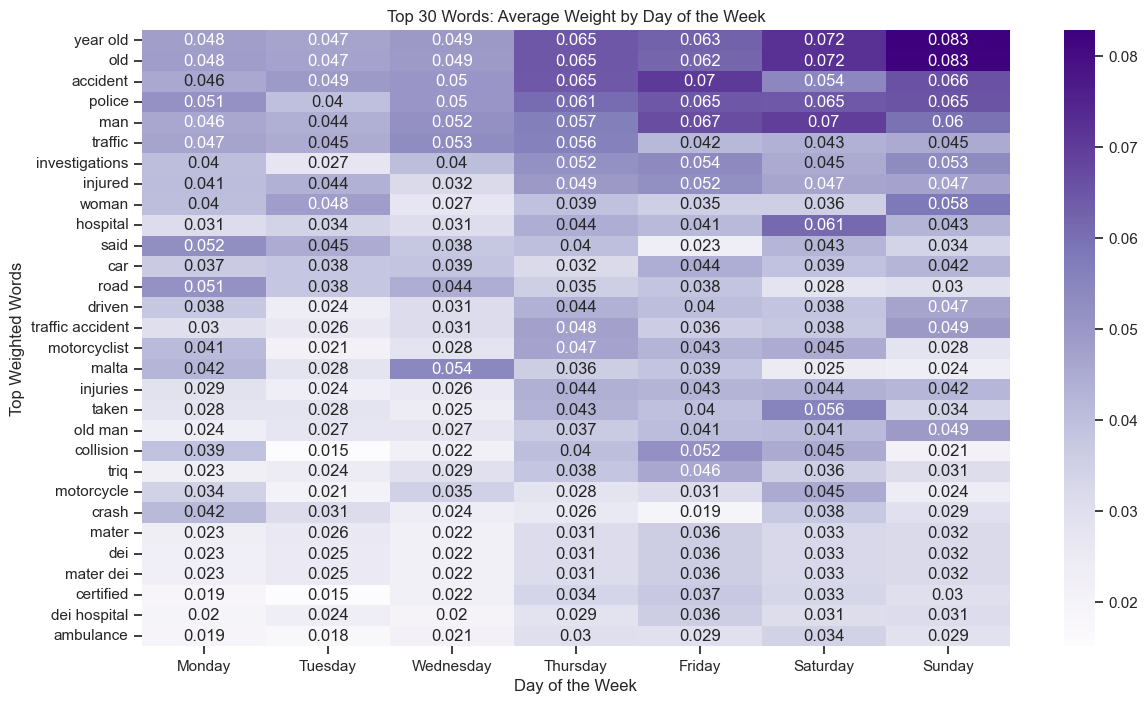

In [99]:
# Group by Day of Week and calculate the average score
word_day_analysis = df_combined.groupby('dow_name')[top_words].mean()

# Reorder the index to ensure Monday-Sunday order
word_day_analysis = word_day_analysis.reindex(day_order)

plt.figure(figsize=(14, 8))
sns.heatmap(word_day_analysis.T, annot=True, cmap="Purples")
plt.title(f'Top {top_n} Words: Average Weight by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Top Weighted Words')
plt.show()

#### Analysis

The multivariate analysis revealed a clear shift from mid-week procedural reporting to weekend "severity" spikes, where terms like "collision" and "hospital" peak on Friday and Saturday followed by a unique demographic focus on Sun,days.

Seasonally, September emerges as the most accident-intensive month, while the variance in word weights across the year proves that timing is a statistically significant predictor of report content.

<hr>

## Creating the target variable

In [117]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def get_word_roots(text):
    # Tokenize (split into words) and Lemmatize each word
    tokens = word_tokenize(str(text).lower())
    roots = [lemmatizer.lemmatize(w) for w in tokens]
    return roots

# Apply this to create a "normalized" version of your content
Finalized_Dataset['content_roots'] = Finalized_Dataset['content'].apply(get_word_roots)


def calculate_severity_robust(root_list):
    # We check the list of roots instead of the raw text
    if any(root in root_list for root in ["die", "dead", "fatal", "death"]):
        return 4
    elif any(root in root_list for root in ["grievous", "serious"]):
        return 3
    elif any(root in root_list for root in ["injury", "hospital", "ambulance", "medical", "mater"]):
        return 2
    elif any(root in root_list for root in ["collision", "crash", "accident"]):
        return 1
    return 0

# Apply to the column of roots we just created
Finalized_Dataset['severity_label'] = Finalized_Dataset['content_roots'].apply(calculate_severity_robust)

# Get all unique words found by your vectorizer
all_vocab = vectorizer.get_feature_names_out()

# Create a dictionary grouping variations by their root
root_map = {}
for word in all_vocab:
    root = lemmatizer.lemmatize(word)
    if root not in root_map:
        root_map[root] = []
    root_map[root].append(word)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\peljo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\peljo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\peljo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


C:\Users\peljo\AppData\Local\Temp\ipykernel_30240\1169221397.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Finalized_Dataset, x='severity_name', order=order, palette="viridis")


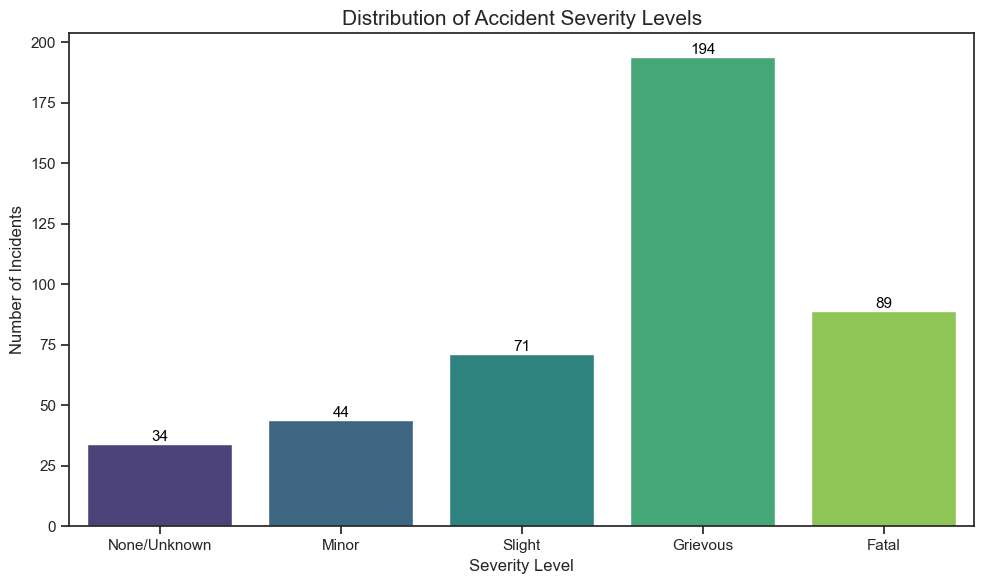

In [ ]:
# Define the labels for the chart
severity_map = {
    0: "None/Unknown",
    1: "Minor",
    2: "Slight",
    3: "Grievous",
    4: "Fatal"
}

# Create a temporary column with labels for the plot
Finalized_Dataset['severity_name'] = Finalized_Dataset['severity_label'].map(severity_map)

# 3. Set the order to ensure the chart goes from lowest to highest severity
order = ["None/Unknown", "Minor", "Slight", "Grievous", "Fatal"]

# 4. Generate the plot
plt.figure(figsize=(10, 6))
sns.countplot(data=Finalized_Dataset, x='severity_name', order=order, palette="viridis")

# Add titles and labels
plt.title('Distribution of Accident Severity Levels', fontsize=15)
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)

# Add value labels on top of each bar for precision
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#Drop temporary columns
Finalized_Dataset = Finalized_Dataset.drop(columns=["severity_name"])
Finalized_Dataset = Finalized_Dataset.drop(columns=["content_roots"])

In [119]:
Finalized_Dataset.to_csv("Datasets/Finalized_Dataset.csv", index=False)